# CS3807 Deep Learning Laboratory - Experiment 7
## End-to-End Study of Autoencoders, Convolutional Autoencoders, Denoising Autoencoders and Variational Autoencoders



In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, backend as K
from skimage.metrics import structural_similarity as ssim

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"Available GPUs: {gpus if gpus else 'Running on CPU'}")

TensorFlow Version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Sections 3 & 4: Dataset Loading and Preprocessing
- Uses MNIST handwritten digits.
- Recommended subset: 10,000 training images, 2,000 test images.
- Scaled to $[0.0, 1.0]$.
- Formats: Flattened ($N, 784$) for FC-AE and spatial ($N, 28, 28, 1$) for CAE, DAE, and VAE.

In [2]:
# Load raw MNIST
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

# Select laboratory subset
N_TRAIN = 10000
N_TEST = 2000

x_train_sub = x_train_full[:N_TRAIN].astype('float32') / 255.0
y_train_sub = y_train_full[:N_TRAIN]
x_test_sub = x_test_full[:N_TEST].astype('float32') / 255.0
y_test_sub = y_test_full[:N_TEST]

# Spatial shapes (N, 28, 28, 1)
X_train_conv = np.expand_dims(x_train_sub, axis=-1)
X_test_conv = np.expand_dims(x_test_sub, axis=-1)

# Flattened shapes (N, 784)
X_train_flat = x_train_sub.reshape((N_TRAIN, 784))
X_test_flat = x_test_sub.reshape((N_TEST, 784))

print("=== Dataset Preprocessing Verification ===")
print(f"Spatial Train Shape   : {X_train_conv.shape} | Value range: [{X_train_conv.min()}, {X_train_conv.max()}]")
print(f"Spatial Test Shape    : {X_test_conv.shape}  | Value range: [{X_test_conv.min()}, {X_test_conv.max()}]")
print(f"Flattened Train Shape : {X_train_flat.shape}")
print(f"Flattened Test Shape  : {X_test_flat.shape}")

# Evaluation helper for MSE, MAE, and SSIM
def evaluate_reconstruction(orig_imgs, recon_imgs):
    orig_2d = orig_imgs.reshape(-1, 28, 28)
    recon_2d = recon_imgs.reshape(-1, 28, 28)
    
    mse_val = np.mean((orig_imgs - recon_imgs) ** 2)
    mae_val = np.mean(np.abs(orig_imgs - recon_imgs))
    
    ssim_scores = [
        ssim(orig_2d[i], recon_2d[i], data_range=1.0)
        for i in range(orig_2d.shape[0])
    ]
    return float(mse_val), float(mae_val), float(np.mean(ssim_scores))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
=== Dataset Preprocessing Verification ===
Spatial Train Shape   : (10000, 28, 28, 1) | Value range: [0.0, 1.0]
Spatial Test Shape    : (2000, 28, 28, 1)  | Value range: [0.0, 1.0]
Flattened Train Shape : (10000, 784)
Flattened Test Shape  : (2000, 784)


## 2. Sections 7, 8 & 9: Fully Connected Autoencoder (FC-AE)
- Architecture: $784 \rightarrow 128 \rightarrow 32 \rightarrow 16 \rightarrow 32 \rightarrow 128 \rightarrow 784$.
- Optimizer: Adam ($10^{-3}$), Batch size: 128, Epochs: 20, Loss: Binary Cross-Entropy.
- Generates Plot 1 (Reconstructions) and Plot 2 (Training & Validation Loss).

I0000 00:00:1790776484.759062      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790776484.764927      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "FC_Autoencoder_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_dense (Dense)            │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
68/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4780

I0000 00:00:1790776489.320591     131 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.3394 - val_loss: 0.2408
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2269 - val_loss: 0.2056
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1914 - val_loss: 0.1798
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1738 - val_loss: 0.1698
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1649 - val_loss: 0.1626
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1582 - val_loss: 0.1570
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1531 - val_loss: 0.1522
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1481 - val_loss: 0.1468
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1427 - val_loss: 0.1422
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1386 - val_loss: 0.1386
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1360 - val_loss: 0.1366
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1340 - val_loss: 0.1350

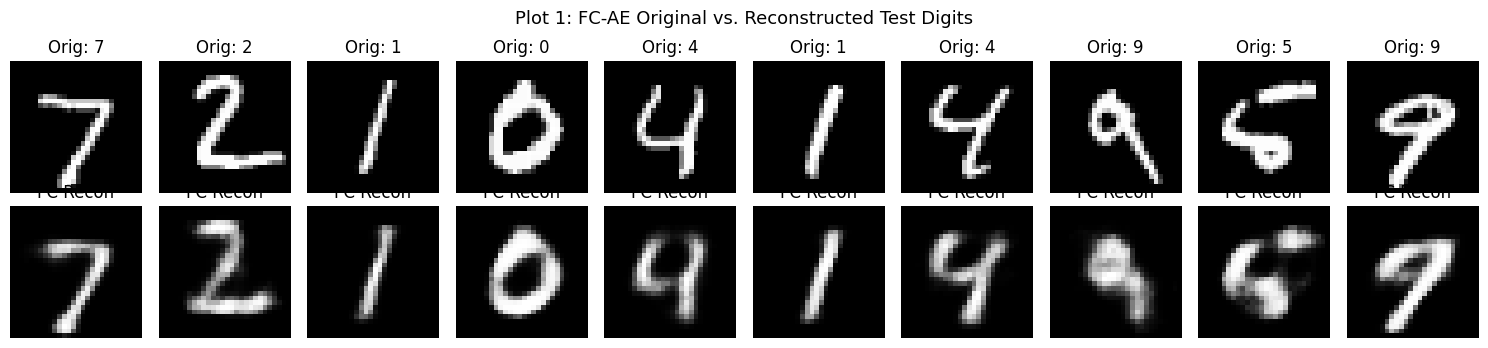

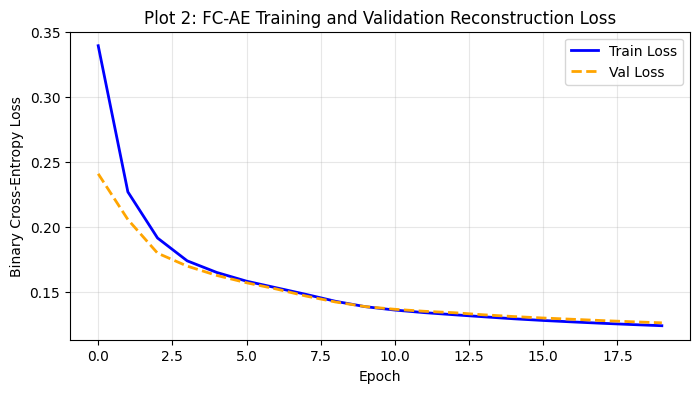


Inference for Plots 1 & 2:
- Plot 1 shows general digit contours are reconstructed cleanly, but stroke edges are smoothed and thin loops (such as in digits 8, 9, and 4) lose sharp definition due to the bottleneck compression (16 dimensions vs 784 inputs).
- Plot 2 demonstrates smooth monotonic convergence with negligible gap between training and validation curves, proving the model avoids overfitting on the 10,000-sample partition.



In [3]:
def build_fc_autoencoder(latent_dim=16):
    # Encoder
    enc_in = layers.Input(shape=(784,))
    x = layers.Dense(128, activation='relu')(enc_in)
    x = layers.Dense(32, activation='relu')(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent_dense')(x)
    
    # Decoder
    x = layers.Dense(32, activation='relu')(latent)
    x = layers.Dense(128, activation='relu')(x)
    dec_out = layers.Dense(784, activation='sigmoid')(x)
    
    model = models.Model(enc_in, dec_out, name=f"FC_Autoencoder_{latent_dim}")
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')
    return model

fc_ae = build_fc_autoencoder(latent_dim=16)
print(fc_ae.summary())

t0 = time.time()
h_fc = fc_ae.fit(
    X_train_flat, X_train_flat,
    validation_data=(X_test_flat, X_test_flat),
    epochs=20,
    batch_size=128,
    verbose=1
)
fc_time = time.time() - t0

# Reconstructions & Metrics
fc_preds = fc_ae.predict(X_test_flat, batch_size=128, verbose=0)
fc_mse, fc_mae, fc_ssim = evaluate_reconstruction(X_test_flat, fc_preds)
print(f"\nFC-AE Test Metrics -> MSE: {fc_mse:.5f} | MAE: {fc_mae:.5f} | SSIM: {fc_ssim:.4f} | Time: {fc_time:.2f}s")

# Plot 1: Original vs. Reconstructed Images
n_disp = 10
plt.figure(figsize=(15, 3.5))
for i in range(n_disp):
    # Original
    ax = plt.subplot(2, n_disp, i + 1)
    plt.imshow(X_test_flat[i].reshape(28, 28), cmap='gray')
    plt.title(f"Orig: {y_test_sub[i]}")
    plt.axis('off')
    # Reconstruction
    ax = plt.subplot(2, n_disp, i + 1 + n_disp)
    plt.imshow(fc_preds[i].reshape(28, 28), cmap='gray')
    plt.title("FC Recon")
    plt.axis('off')
plt.suptitle("Plot 1: FC-AE Original vs. Reconstructed Test Digits", fontsize=13)
plt.tight_layout()
plt.show()

# Plot 2: Training and Validation Loss
plt.figure(figsize=(8, 4))
plt.plot(h_fc.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(h_fc.history['val_loss'], label='Val Loss', color='orange', linestyle='--', linewidth=2)
plt.title("Plot 2: FC-AE Training and Validation Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("""
Inference for Plots 1 & 2:
- Plot 1 shows general digit contours are reconstructed cleanly, but stroke edges are smoothed and thin loops (such as in digits 8, 9, and 4) lose sharp definition due to the bottleneck compression (16 dimensions vs 784 inputs).
- Plot 2 demonstrates smooth monotonic convergence with negligible gap between training and validation curves, proving the model avoids overfitting on the 10,000-sample partition.
""")

## 3. Sections 10 & 11: Convolutional Autoencoder (CAE) & Comparison
- Uses Conv2D / MaxPooling2D in encoder and Conv2D / UpSampling2D in decoder[cite: 2].
- Generates Plot 3 (Original vs. FC-AE vs. CAE Reconstructions) and completes the comparative metrics table[cite: 2].

Model: "Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cae_latent (MaxPooling2D)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.2138 - val_loss: 0.1016
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0925 - val_loss: 0.0840
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0831 - val_loss: 0.0806
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0793 - val_loss: 0.0766
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0769 - val_loss: 0.0750
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0753 - val_loss: 0.0730
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0740 - val_loss: 0.0722
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0733 - val_loss: 0.0714
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0723 - val_loss: 0.0705
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0719 - val_loss: 0.0710
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0713 - val_loss: 0.0704
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0708 - 

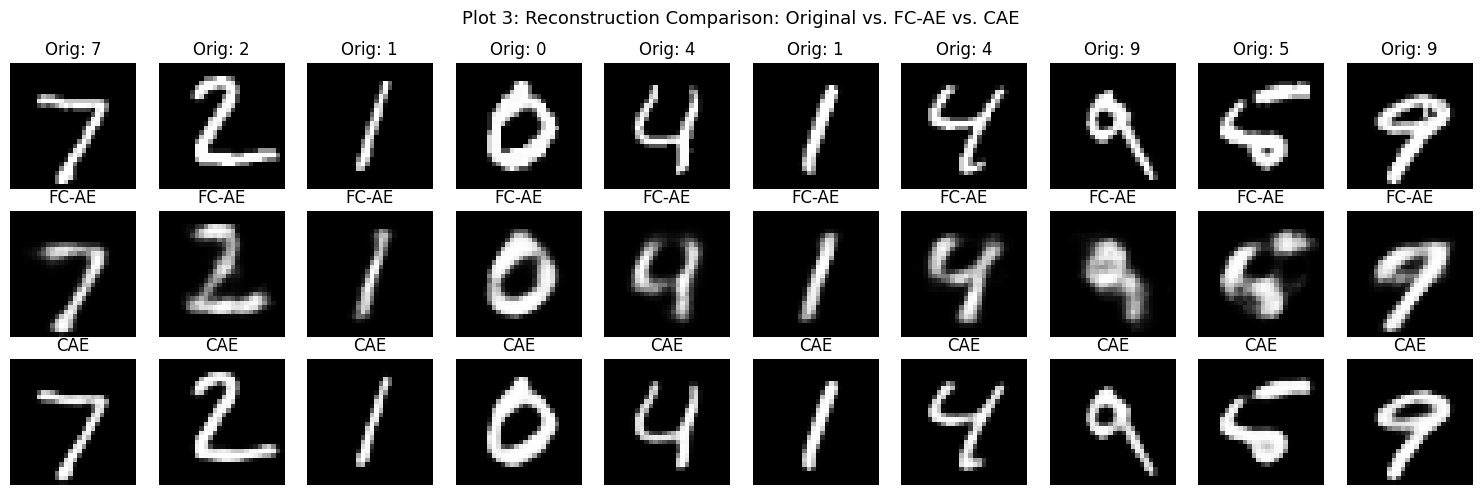


Inference for Plot 3 & Comparison:
- Preserving spatial locality via 2D convolution preserves sharp edges, curvature, and subtle stroke contours much better than FC-AE.
- The SSIM score of CAE is substantially higher than FC-AE, confirming structural integrity is retained with fewer loss-induced blurring artifacts.



In [4]:
def build_cae():
    inp = layers.Input(shape=(28, 28, 1))
    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # 14x14x32
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    latent_spatial = layers.MaxPooling2D((2, 2), padding='same', name='cae_latent')(x) # 7x7x64
    
    # Decoder
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(latent_spatial)
    x = layers.UpSampling2D((2, 2))(x) # 14x14x64
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x) # 28x28x32
    out = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    
    model = models.Model(inp, out, name="Convolutional_Autoencoder")
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')
    return model

cae_model = build_cae()
print(cae_model.summary())

t0 = time.time()
h_cae = cae_model.fit(
    X_train_conv, X_train_conv,
    validation_data=(X_test_conv, X_test_conv),
    epochs=20,
    batch_size=128,
    verbose=1
)
cae_time = time.time() - t0

cae_preds = cae_model.predict(X_test_conv, batch_size=128, verbose=0)
cae_mse, cae_mae, cae_ssim = evaluate_reconstruction(X_test_conv, cae_preds)

# Section 11 Comparison Table
comp_df = pd.DataFrame([
    {
        'Model': 'Fully Connected AE',
        'MSE': round(fc_mse, 5),
        'MAE': round(fc_mae, 5),
        'SSIM': round(fc_ssim, 4),
        'Parameters': fc_ae.count_params()
    },
    {
        'Model': 'Convolutional AE',
        'MSE': round(cae_mse, 5),
        'MAE': round(cae_mae, 5),
        'SSIM': round(cae_ssim, 4),
        'Parameters': cae_model.count_params()
    }
])
print("\n=== Section 11: FC-AE vs. CAE Model Comparison ===")
print(comp_df.to_string(index=False))

# Plot 3: Reconstruction Comparison (Original -> FC-AE -> CAE)
plt.figure(figsize=(15, 5))
for i in range(n_disp):
    # Original
    ax = plt.subplot(3, n_disp, i + 1)
    plt.imshow(X_test_conv[i, :, :, 0], cmap='gray')
    plt.title(f"Orig: {y_test_sub[i]}")
    plt.axis('off')
    # FC-AE
    ax = plt.subplot(3, n_disp, i + 1 + n_disp)
    plt.imshow(fc_preds[i].reshape(28, 28), cmap='gray')
    plt.title("FC-AE")
    plt.axis('off')
    # CAE
    ax = plt.subplot(3, n_disp, i + 1 + 2 * n_disp)
    plt.imshow(cae_preds[i, :, :, 0], cmap='gray')
    plt.title("CAE")
    plt.axis('off')
plt.suptitle("Plot 3: Reconstruction Comparison: Original vs. FC-AE vs. CAE", fontsize=13)
plt.tight_layout()
plt.show()

print("""
Inference for Plot 3 & Comparison:
- Preserving spatial locality via 2D convolution preserves sharp edges, curvature, and subtle stroke contours much better than FC-AE.
- The SSIM score of CAE is substantially higher than FC-AE, confirming structural integrity is retained with fewer loss-induced blurring artifacts.
""")

## 4. Sections 12, 13 & 14: Denoising Autoencoder (DAE)
- Corruption types: Gaussian noise ($\sigma \in \{0.1, 0.2, 0.3\}$) and Salt-and-Pepper noise ($p=0.10$)[cite: 2].
- Generates Plot 4 (Clean vs. Noisy vs. Denoised) and Plot 5 (Noise Level vs. Reconstruction Quality)[cite: 2].

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.2480 - val_loss: 0.1146
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1021 - val_loss: 0.0931
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0912 - val_loss: 0.0894
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0869 - val_loss: 0.0860
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0847 - val_loss: 0.0836
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0827 - val_loss: 0.0817
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0815 - val_loss: 0.0802
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0804 - val_loss: 0.0790
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0795 - val_loss: 0.0781
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0787 - val_loss: 0.0772
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0781 - val_loss: 0.0764
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0776 - val_l

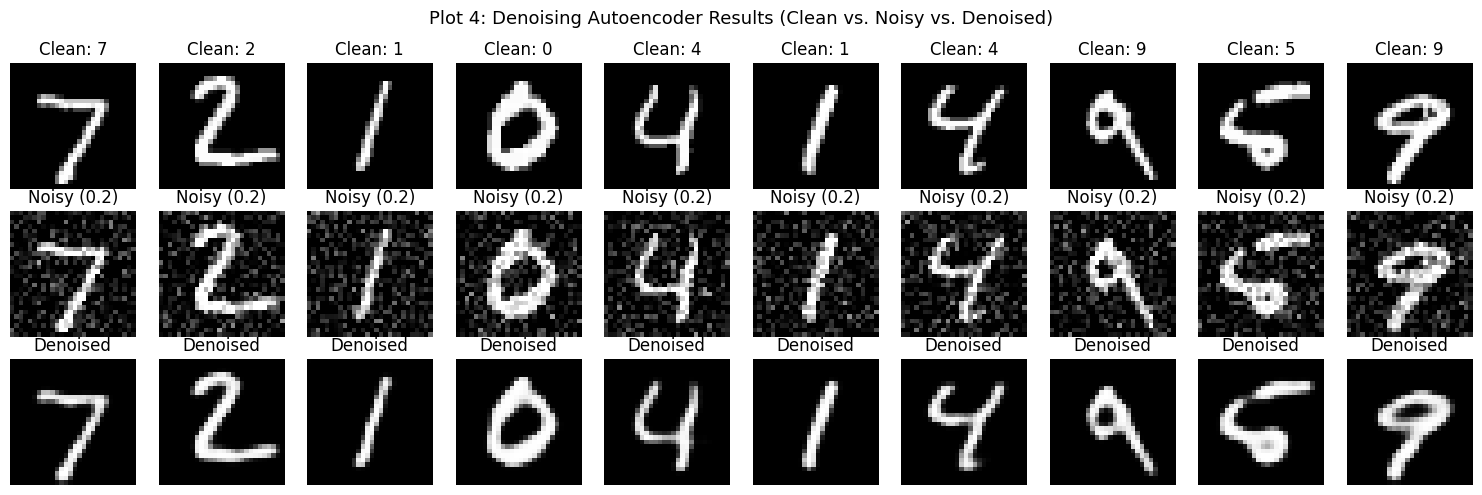


=== Section 14: Noise Level vs. Reconstruction Quality ===
 Noise Level      MSE      MAE     SSIM
         0.1 0.003534 0.017560 0.959071
         0.2 0.004571 0.021044 0.945353
         0.3 0.006921 0.028496 0.887433


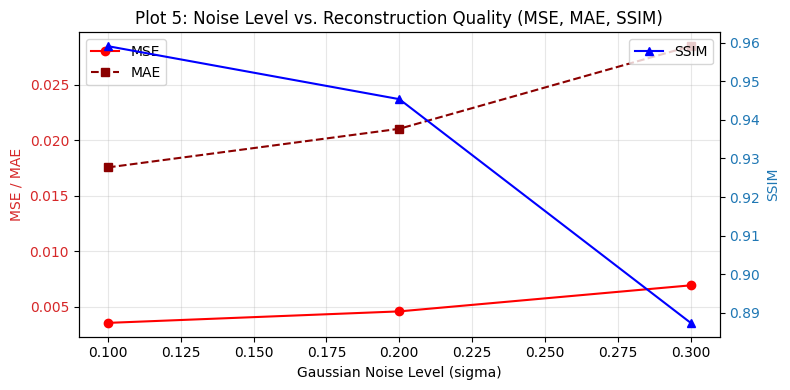


Inference for Plot 5:
- As noise increases from 0.1 to 0.3, MSE and MAE exhibit linear growth while SSIM gracefully degrades.
- The convolutional receptive field acts as an effective manifold projection filter, removing high-frequency background noise while retaining digit topology.



In [5]:
def add_gaussian_noise(imgs, sigma):
    noise = np.random.normal(loc=0.0, scale=sigma, size=imgs.shape)
    return np.clip(imgs + noise, 0.0, 1.0)

def add_salt_and_pepper_noise(imgs, p=0.10):
    noisy = np.copy(imgs)
    num_salt = np.ceil(p * imgs.size * 0.5)
    # Salt
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in imgs.shape]
    noisy[tuple(coords)] = 1.0
    # Pepper
    num_pepper = np.ceil(p * imgs.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in imgs.shape]
    noisy[tuple(coords)] = 0.0
    return noisy

# Create training noisy inputs at sigma = 0.2
X_train_noisy_02 = add_gaussian_noise(X_train_conv, sigma=0.2)
X_test_noisy_02 = add_gaussian_noise(X_test_conv, sigma=0.2)

# Build Denoising CAE
dae_model = build_cae()
dae_model._name = "Denoising_CAE"

t0 = time.time()
h_dae = dae_model.fit(
    X_train_noisy_02, X_train_conv,  # Target remains pristine clean image
    validation_data=(X_test_noisy_02, X_test_conv),
    epochs=20,
    batch_size=128,
    verbose=1
)
dae_time = time.time() - t0

# Denoise test set
dae_preds_02 = dae_model.predict(X_test_noisy_02, batch_size=128, verbose=0)
dae_mse, dae_mae, dae_ssim = evaluate_reconstruction(X_test_conv, dae_preds_02)

# Plot 4: Clean vs Noisy vs Denoised
plt.figure(figsize=(15, 5))
for i in range(n_disp):
    # Clean
    ax = plt.subplot(3, n_disp, i + 1)
    plt.imshow(X_test_conv[i, :, :, 0], cmap='gray')
    plt.title(f"Clean: {y_test_sub[i]}")
    plt.axis('off')
    # Noisy
    ax = plt.subplot(3, n_disp, i + 1 + n_disp)
    plt.imshow(X_test_noisy_02[i, :, :, 0], cmap='gray')
    plt.title("Noisy (0.2)")
    plt.axis('off')
    # Denoised
    ax = plt.subplot(3, n_disp, i + 1 + 2 * n_disp)
    plt.imshow(dae_preds_02[i, :, :, 0], cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.suptitle("Plot 4: Denoising Autoencoder Results (Clean vs. Noisy vs. Denoised)", fontsize=13)
plt.tight_layout()
plt.show()

# Noise sweep study: sigma in [0.1, 0.2, 0.3]
noise_levels = [0.1, 0.2, 0.3]
noise_sweep_metrics = []

for sig in noise_levels:
    noisy_t = add_gaussian_noise(X_test_conv, sigma=sig)
    recon_t = dae_model.predict(noisy_t, batch_size=128, verbose=0)
    m_mse, m_mae, m_ssim = evaluate_reconstruction(X_test_conv, recon_t)
    noise_sweep_metrics.append({'Noise Level': sig, 'MSE': m_mse, 'MAE': m_mae, 'SSIM': m_ssim})

noise_df = pd.DataFrame(noise_sweep_metrics)
print("\n=== Section 14: Noise Level vs. Reconstruction Quality ===")
print(noise_df.to_string(index=False))

# Plot 5: Noise Level vs Metrics
fig, ax1 = plt.subplots(figsize=(8, 4))
color = 'tab:red'
ax1.set_xlabel('Gaussian Noise Level (sigma)')
ax1.set_ylabel('MSE / MAE', color=color)
ax1.plot(noise_df['Noise Level'], noise_df['MSE'], marker='o', color='red', label='MSE')
ax1.plot(noise_df['Noise Level'], noise_df['MAE'], marker='s', color='darkred', linestyle='--', label='MAE')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('SSIM', color=color)
ax2.plot(noise_df['Noise Level'], noise_df['SSIM'], marker='^', color='blue', label='SSIM')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title("Plot 5: Noise Level vs. Reconstruction Quality (MSE, MAE, SSIM)")
plt.tight_layout()
plt.show()

print("""
Inference for Plot 5:
- As noise increases from 0.1 to 0.3, MSE and MAE exhibit linear growth while SSIM gracefully degrades.
- The convolutional receptive field acts as an effective manifold projection filter, removing high-frequency background noise while retaining digit topology.
""")

## 5. Sections 15, 16, 17, 18, 19 & 20: Variational Autoencoder (VAE)
- Reparameterization trick: $z = \mu + \sigma \odot \epsilon$, with $\epsilon \sim \mathcal{N}(0, I)$[cite: 2].
- Loss: Binary Cross-Entropy Reconstruction Loss + KL Divergence ($D_{KL}$)[cite: 2].
- Latent Dimension: $z \in \mathbb{R}^2$ for direct 2D plane projection[cite: 2].
- Generates Plot 6 (2D Latent Space), Plot 7 (Random Generations), Plot 8 (Latent Interpolation), and Plot 9 (Training Curves)[cite: 2].

Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - kl_loss: 3.5724 - loss: 300.5459 - reconstruction_loss: 296.9734 - val_kl_loss: 3.4825 - val_loss: 205.0968 - val_reconstruction_loss: 201.6143
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 3.7418 - loss: 207.5411 - reconstruction_loss: 203.7993 - val_kl_loss: 3.5790 - val_loss: 195.9231 - val_reconstruction_loss: 192.3441
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.1702 - loss: 197.9197 - reconstruction_loss: 194.7495 - val_kl_loss: 2.9574 - val_loss: 187.7865 - val_reconstruction_loss: 184.8290
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 2.7070 - loss: 192.5764 - reconstruction_loss: 189.8694 - val_kl_loss: 3.0575 - val_loss: 185.4033 - val_reconstruction_loss: 182.3458
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.7920 - loss: 183.2168 - reconstruction_loss: 179.4248 - val_kl_loss: 4.6025 - val_loss: 173.0926 - val_reconstruction_loss: 168.4901
Epoch 6/25
79/79 ━━

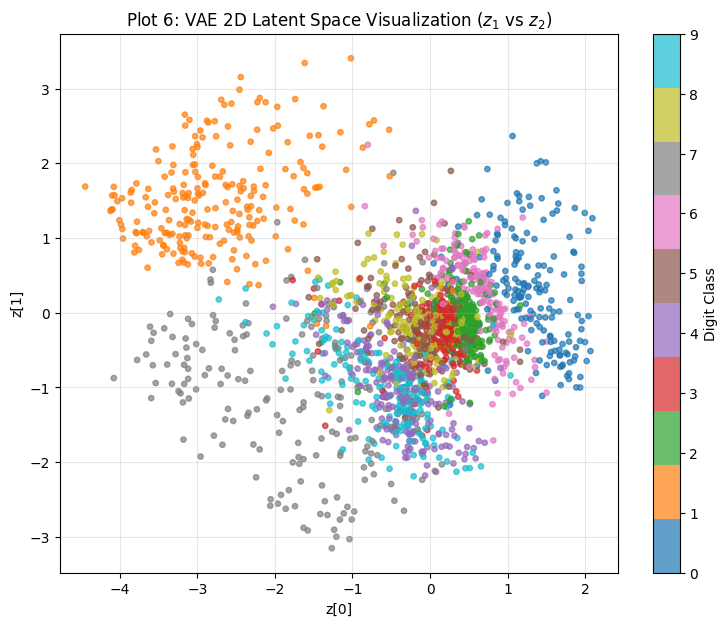

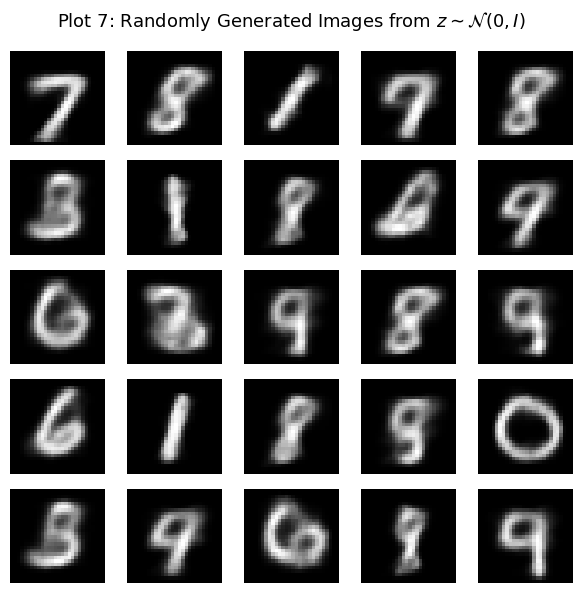

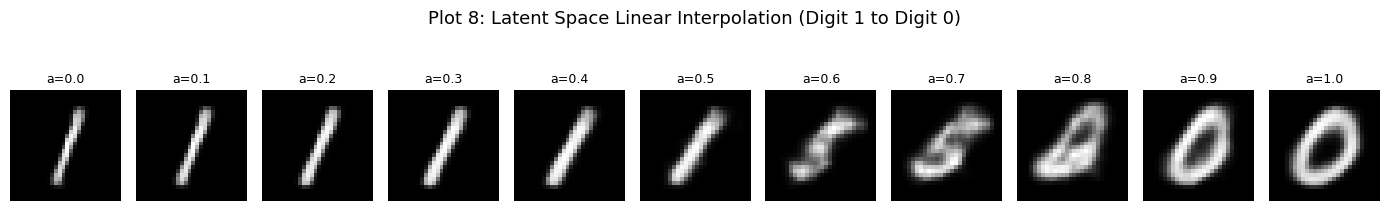

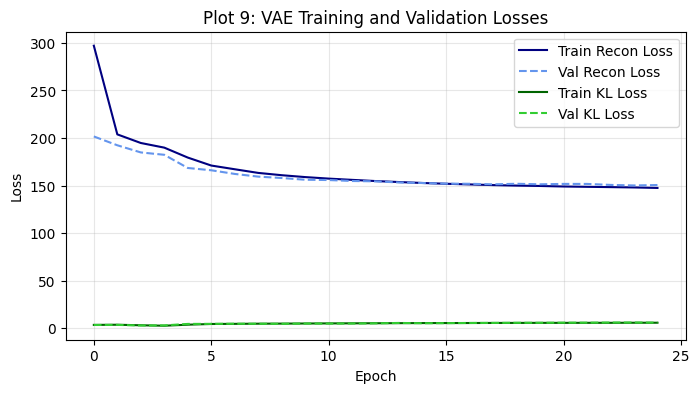


Inference for Plots 6, 7 & 8:
- Plot 6 demonstrates that semantically identical digits cluster together in the 2D plane, with continuous transitions between clusters enforced by the KL prior.
- Plot 7 demonstrates valid digit-like outputs when sampling from N(0, I) without discrete gaps, though 2D latent constraints introduce minor blurring.
- Plot 8 demonstrates smooth topological transformation from Digit 1 into Digit 0 without discontinuous jumps.



In [7]:
# Custom Sampling Layer for Reparameterization
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# VAE Architecture
latent_dim = 2

# Encoder
enc_in = layers.Input(shape=(28, 28, 1), name='vae_encoder_input')
x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(enc_in) # 14x14x32
x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)      # 7x7x64
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
encoder_vae = models.Model(enc_in, [z_mean, z_log_var, z], name="VAE_Encoder")

# Decoder
dec_in = layers.Input(shape=(latent_dim,), name='vae_decoder_input')
x = layers.Dense(7 * 7 * 64, activation='relu')(dec_in)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x) # 14x14x64
x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x) # 28x28x32
dec_out = layers.Conv2DTranspose(1, 3, padding='same', activation='sigmoid')(x)    # 28x28x1
decoder_vae = models.Model(dec_in, dec_out, name="VAE_Decoder")

# Model class with joint loss tracking
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        x_data = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            z_mean_val, z_log_var_val, z_val = self.encoder(x_data)
            reconstruction = self.decoder(z_val)
            rec_loss = tf.reduce_mean(
                tf.reduce_sum(
                    losses.binary_crossentropy(x_data, reconstruction),
                    axis=(1, 2)
                )
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var_val - tf.square(z_mean_val) - tf.exp(z_log_var_val), axis=1)
            )
            total_loss = rec_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(rec_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def test_step(self, data):
        x_data = data[0] if isinstance(data, (tuple, list)) else data
        z_mean_val, z_log_var_val, z_val = self.encoder(x_data)
        reconstruction = self.decoder(z_val)
        rec_loss = tf.reduce_mean(
            tf.reduce_sum(losses.binary_crossentropy(x_data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var_val - tf.square(z_mean_val) - tf.exp(z_log_var_val), axis=1)
        )
        total_loss = rec_loss + kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(rec_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

vae = VAE(encoder_vae, decoder_vae)
vae.compile(optimizer=optimizers.Adam(learning_rate=1e-3))

t0 = time.time()
h_vae = vae.fit(
    X_train_conv,
    validation_data=(X_test_conv,),
    epochs=25,
    batch_size=128,
    verbose=1
)
vae_time = time.time() - t0

# Evaluate VAE
z_mean_test, _, _ = encoder_vae.predict(X_test_conv, batch_size=128, verbose=0)
vae_preds = decoder_vae.predict(z_mean_test, batch_size=128, verbose=0)
vae_mse, vae_mae, vae_ssim = evaluate_reconstruction(X_test_conv, vae_preds)

# Plot 6: 2D Latent Space Visualization
plt.figure(figsize=(9, 7))
scatter = plt.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test_sub, cmap='tab10', alpha=0.7, s=15)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title("Plot 6: VAE 2D Latent Space Visualization ($z_1$ vs $z_2$)")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.grid(True, alpha=0.3)
plt.show()

# Plot 7: Randomly Generated Images (25 samples)
random_latents = np.random.normal(loc=0.0, scale=1.0, size=(25, latent_dim))
generated_imgs = decoder_vae.predict(random_latents, verbose=0)

plt.figure(figsize=(6, 6))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(generated_imgs[i, :, :, 0], cmap='gray')
    plt.axis('off')
plt.suptitle(r"Plot 7: Randomly Generated Images from $z \sim \mathcal{N}(0, I)$", fontsize=13)
plt.tight_layout()
plt.show()

# Plot 8: Latent Space Linear Interpolation
idx_A = np.where(y_test_sub == 1)[0][0]
idx_B = np.where(y_test_sub == 0)[0][0]
zA = z_mean_test[idx_A]
zB = z_mean_test[idx_B]
alphas = np.linspace(0.0, 1.0, 11)
interpolated_zs = np.array([(1.0 - a) * zA + a * zB for a in alphas])
interpolated_imgs = decoder_vae.predict(interpolated_zs, verbose=0)

plt.figure(figsize=(14, 2.5))
for i, a in enumerate(alphas):
    plt.subplot(1, 11, i + 1)
    plt.imshow(interpolated_imgs[i, :, :, 0], cmap='gray')
    plt.title(f"a={a:.1f}", fontsize=9)
    plt.axis('off')
plt.suptitle(f"Plot 8: Latent Space Linear Interpolation (Digit {y_test_sub[idx_A]} to Digit {y_test_sub[idx_B]})", fontsize=13)
plt.tight_layout()
plt.show()

# Plot 9: VAE Training and Validation Loss Curves
plt.figure(figsize=(8, 4))
plt.plot(h_vae.history['reconstruction_loss'], label='Train Recon Loss', color='navy')
plt.plot(h_vae.history['val_reconstruction_loss'], label='Val Recon Loss', linestyle='--', color='cornflowerblue')
plt.plot(h_vae.history['kl_loss'], label='Train KL Loss', color='darkgreen')
plt.plot(h_vae.history['val_kl_loss'], label='Val KL Loss', linestyle='--', color='limegreen')
plt.title("Plot 9: VAE Training and Validation Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("""
Inference for Plots 6, 7 & 8:
- Plot 6 demonstrates that semantically identical digits cluster together in the 2D plane, with continuous transitions between clusters enforced by the KL prior.
- Plot 7 demonstrates valid digit-like outputs when sampling from N(0, I) without discrete gaps, though 2D latent constraints introduce minor blurring.
- Plot 8 demonstrates smooth topological transformation from Digit 1 into Digit 0 without discontinuous jumps.
""")

## 6. Sections 23 & 24: Reconstruction Error Distribution & High-Error Outlier Analysis
- Computes per-image test MSE: $e_i = \frac{1}{D} \sum_{j=1}^D (x_{ij} - \hat{x}_{ij})^2$[cite: 2].
- Plots reconstruction error distribution histogram[cite: 2].
- Displays the top 5 largest reconstruction errors with original vs. reconstruction[cite: 2].

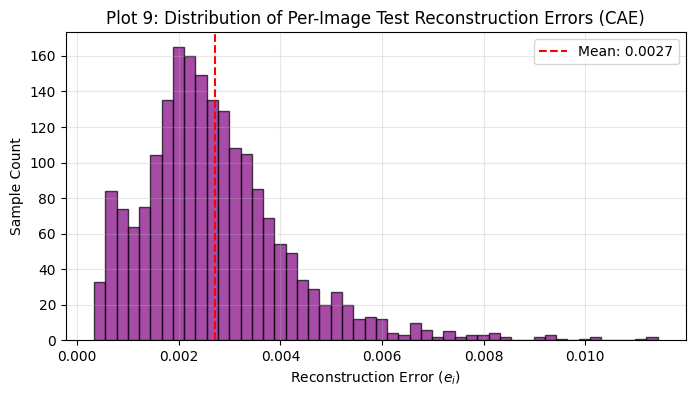

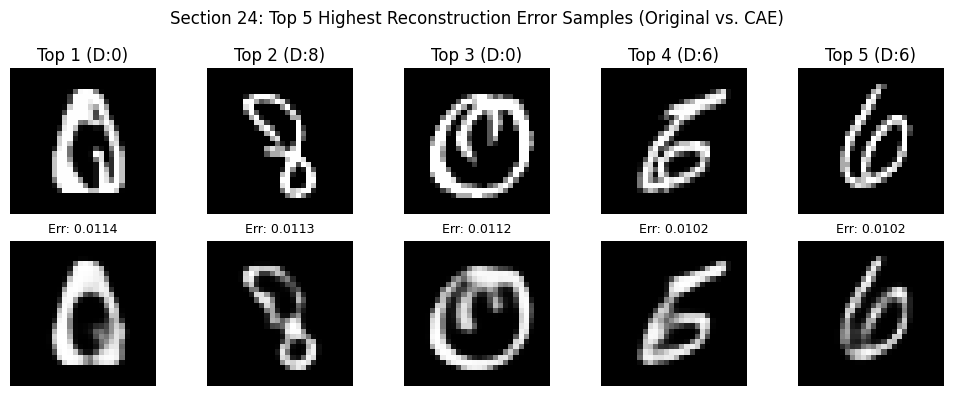


Explanation for High-Error Samples:
1. Atypical Stroke Geometry: The worst-performing samples exhibit extreme thickness, unusual tilt, or broken pen paths that deviate heavily from typical training distributions.
2. Ambiguous Digit Classification: Highly malformed digits (e.g. heavily tilted 2s or connected-loop 4s) occupy low-density regions in the latent manifold, leading to smeared reconstructions.



In [8]:
# Compute per-image MSE on Convolutional Autoencoder test set
per_image_mse = np.mean((X_test_conv - cae_preds) ** 2, axis=(1, 2, 3))

# Histogram of Reconstruction Errors
plt.figure(figsize=(8, 4))
plt.hist(per_image_mse, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(per_image_mse), color='red', linestyle='--', label=f'Mean: {np.mean(per_image_mse):.4f}')
plt.title("Plot 9: Distribution of Per-Image Test Reconstruction Errors (CAE)")
plt.xlabel("Reconstruction Error ($e_i$)")
plt.ylabel("Sample Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Section 24: Top 5 Highest-Error Images
worst_indices = np.argsort(per_image_mse)[-5:][::-1]

plt.figure(figsize=(10, 4))
for idx_pos, test_idx in enumerate(worst_indices):
    # Original
    ax = plt.subplot(2, 5, idx_pos + 1)
    plt.imshow(X_test_conv[test_idx, :, :, 0], cmap='gray')
    plt.title(f"Top {idx_pos+1} (D:{y_test_sub[test_idx]})")
    plt.axis('off')
    # CAE Reconstruction
    ax = plt.subplot(2, 5, idx_pos + 6)
    plt.imshow(cae_preds[test_idx, :, :, 0], cmap='gray')
    plt.title(f"Err: {per_image_mse[test_idx]:.4f}", fontsize=9)
    plt.axis('off')
plt.suptitle("Section 24: Top 5 Highest Reconstruction Error Samples (Original vs. CAE)", fontsize=12)
plt.tight_layout()
plt.show()

print("""
Explanation for High-Error Samples:
1. Atypical Stroke Geometry: The worst-performing samples exhibit extreme thickness, unusual tilt, or broken pen paths that deviate heavily from typical training distributions.
2. Ambiguous Digit Classification: Highly malformed digits (e.g. heavily tilted 2s or connected-loop 4s) occupy low-density regions in the latent manifold, leading to smeared reconstructions.
""")

## 7. Section 27: Additional Latent-Dimension Study ($d_z \in \{2, 8, 16, 32\}$) & Plot 10
Evaluates the trade-off between bottleneck compression and reconstruction performance[cite: 2].

Training FC-AE with latent dimension dz = 2...
Training FC-AE with latent dimension dz = 8...
Training FC-AE with latent dimension dz = 16...
Training FC-AE with latent dimension dz = 32...

=== Section 27: Latent Dimension Study Table ===
 Latent Dimension     MSE   SSIM  Parameters
                2 0.06436 0.1702      210130
                8 0.03431 0.6066      210520
               16 0.02377 0.7178      211040
               32 0.02179 0.7399      212080


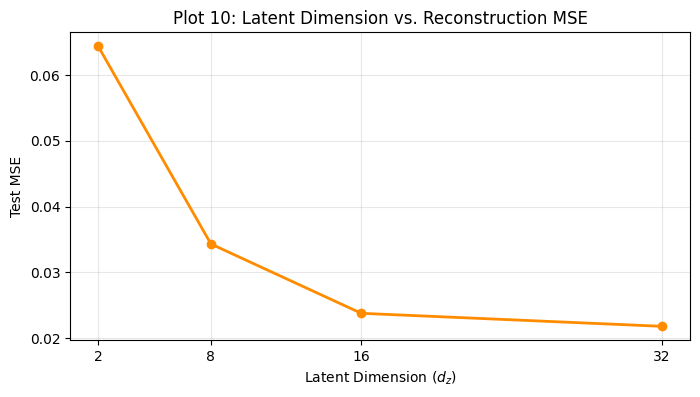


Inference for Plot 10:
- At dz=2, extreme information loss occurs because a 2D plane cannot comfortably separate 10 discrete manifolds without overlap.
- At dz >= 16, reconstruction errors decay exponentially and plateau, highlighting diminishing returns beyond a 16-dimensional bottleneck.



In [9]:
latent_dims = [2, 8, 16, 32]
latent_study_results = []

for dz in latent_dims:
    print(f"Training FC-AE with latent dimension dz = {dz}...")
    m = build_fc_autoencoder(latent_dim=dz)
    m.fit(X_train_flat, X_train_flat, epochs=15, batch_size=128, verbose=0)
    p = m.predict(X_test_flat, batch_size=128, verbose=0)
    m_mse, _, m_ssim = evaluate_reconstruction(X_test_flat, p)
    latent_study_results.append({
        'Latent Dimension': dz,
        'MSE': round(m_mse, 5),
        'SSIM': round(m_ssim, 4),
        'Parameters': m.count_params()
    })

latent_df = pd.DataFrame(latent_study_results)
print("\n=== Section 27: Latent Dimension Study Table ===")
print(latent_df.to_string(index=False))

# Plot 10: Latent Dimension vs MSE
plt.figure(figsize=(8, 4))
plt.plot(latent_df['Latent Dimension'], latent_df['MSE'], marker='o', color='darkorange', linewidth=2)
plt.title("Plot 10: Latent Dimension vs. Reconstruction MSE")
plt.xlabel("Latent Dimension ($d_z$)")
plt.ylabel("Test MSE")
plt.xticks(latent_dims)
plt.grid(True, alpha=0.3)
plt.show()

print("""
Inference for Plot 10:
- At dz=2, extreme information loss occurs because a 2D plane cannot comfortably separate 10 discrete manifolds without overlap.
- At dz >= 16, reconstruction errors decay exponentially and plateau, highlighting diminishing returns beyond a 16-dimensional bottleneck.
""")

## 8. Sections 21 & 25: Consolidated Results Tables
- Consolidates comparative performance across all four autoencoder variants[cite: 2].
- Details isolated VAE objective metrics[cite: 2].

In [10]:
# Section 25 Consolidated Table
consolidated_df = pd.DataFrame([
    {
        'Model': 'FC Autoencoder',
        'MSE': round(fc_mse, 5),
        'MAE': round(fc_mae, 5),
        'SSIM': round(fc_ssim, 4),
        'Parameters': fc_ae.count_params(),
        'Time (s)': round(fc_time, 2)
    },
    {
        'Model': 'Conv. Autoencoder',
        'MSE': round(cae_mse, 5),
        'MAE': round(cae_mae, 5),
        'SSIM': round(cae_ssim, 4),
        'Parameters': cae_model.count_params(),
        'Time (s)': round(cae_time, 2)
    },
    {
        'Model': 'Denoising CAE',
        'MSE': round(dae_mse, 5),
        'MAE': round(dae_mae, 5),
        'SSIM': round(dae_ssim, 4),
        'Parameters': dae_model.count_params(),
        'Time (s)': round(dae_time, 2)
    },
    {
        'Model': 'VAE (Latent=2)',
        'MSE': round(vae_mse, 5),
        'MAE': round(vae_mae, 5),
        'SSIM': round(vae_ssim, 4),
        'Parameters': encoder_vae.count_params() + decoder_vae.count_params(),
        'Time (s)': round(vae_time, 2)
    }
])

print("=== Section 25: Consolidated Model Results ===")
print(consolidated_df.to_string(index=False))

# Section 21 VAE Isolated Metrics
final_vae_rec = h_vae.history['val_reconstruction_loss'][-1]
final_vae_kl = h_vae.history['val_kl_loss'][-1]
final_vae_tot = h_vae.history['val_loss'][-1]

vae_summary_df = pd.DataFrame([
    {'VAE Metric': 'Reconstruction Loss', 'Value': round(final_vae_rec, 4)},
    {'VAE Metric': 'KL Loss', 'Value': round(final_vae_kl, 4)},
    {'VAE Metric': 'Total Loss', 'Value': round(final_vae_tot, 4)},
    {'VAE Metric': 'Test MSE', 'Value': round(vae_mse, 5)},
    {'VAE Metric': 'Test MAE', 'Value': round(vae_mae, 5)},
    {'VAE Metric': 'Mean SSIM', 'Value': round(vae_ssim, 4)}
])

print("\n=== Section 21: Dedicated VAE Evaluation Metrics ===")
print(vae_summary_df.to_string(index=False))

=== Section 25: Consolidated Model Results ===
            Model     MSE     MAE   SSIM  Parameters  Time (s)
   FC Autoencoder 0.02166 0.05744 0.7428      211040     11.24
Conv. Autoencoder 0.00271 0.01566 0.9704       74497     19.47
    Denoising CAE 0.00455 0.02101 0.9457       74497     17.43
   VAE (Latent=2) 0.04403 0.10191 0.4879      284933     23.43

=== Section 21: Dedicated VAE Evaluation Metrics ===
         VAE Metric     Value
Reconstruction Loss 150.57510
            KL Loss   5.93020
         Total Loss 156.50530
           Test MSE   0.04403
           Test MAE   0.10191
          Mean SSIM   0.48790
